# SECTION 1: DATASET LOADING
## Load Parkinson's Spiral Images

**Dataset**: Parkinson's Image Dataset (PID) - Spiral images only

**Structure**:
- Training: 72 images (36 Healthy, 36 Parkinson's)
- Image size: 128 × 128 × 3 (RGB)
- Labels: 0 = Healthy, 1 = Parkinson's
- Format: CMGY (treated as RGB)

In [31]:
import numpy as np
import cv2
from pathlib import Path
import kagglehub

np.random.seed(42)
print("Libraries imported successfully!")

Libraries imported successfully!


In [32]:
def cmgy_to_grayscale(img):
    """Convert CMGY format image to grayscale directly (no RGB intermediate)"""
    if len(img.shape) == 3 and img.shape[2] == 4:
        # Extract CMGY channels
        c = img[:, :, 0].astype(np.float32)
        m = img[:, :, 1].astype(np.float32)
        g = img[:, :, 2].astype(np.float32)
        y = img[:, :, 3].astype(np.float32)
        
        # Direct CMGY to grayscale: weighted combination of all channels
        # Preserves all CMGY information without RGB conversion
        gray = (0.3 * c + 0.3 * m + 0.2 * g + 0.2 * y).astype(np.uint8)
        return gray
    else:
        # 3-channel BGR image
        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
        return gray

In [33]:
dataset_path = kagglehub.dataset_download("kmader/parkinsons-drawings")
print(f"Dataset downloaded to: {dataset_path}")

dataset_root = Path(dataset_path)

training_dir = dataset_root / 'spiral' / 'training'
train_images = []
train_labels = []

healthy_dir = training_dir / 'healthy'
for img_file in sorted(healthy_dir.glob('*.png')):
    img = cv2.imread(str(img_file), cv2.IMREAD_UNCHANGED)
    if img is not None:
        img = cmgy_to_grayscale(img)
        img = cv2.resize(img, (128, 128))
        train_images.append(img)
        train_labels.append(0)

parkinson_dir = training_dir / 'parkinson'
for img_file in sorted(parkinson_dir.glob('*.png')):
    img = cv2.imread(str(img_file), cv2.IMREAD_UNCHANGED)
    if img is not None:
        img = cmgy_to_grayscale(img)
        img = cv2.resize(img, (128, 128))
        train_images.append(img)
        train_labels.append(1)

X_train = np.array(train_images, dtype=np.uint8)
y_train = np.array(train_labels)

testing_dir = dataset_root / 'spiral' / 'testing'
test_images = []
test_labels = []

healthy_dir = testing_dir / 'healthy'
for img_file in sorted(healthy_dir.glob('*.png')):
    img = cv2.imread(str(img_file), cv2.IMREAD_UNCHANGED)
    if img is not None:
        img = cmgy_to_grayscale(img)
        img = cv2.resize(img, (128, 128))
        test_images.append(img)
        test_labels.append(0)

parkinson_dir = testing_dir / 'parkinson'
for img_file in sorted(parkinson_dir.glob('*.png')):
    img = cv2.imread(str(img_file), cv2.IMREAD_UNCHANGED)
    if img is not None:
        img = cmgy_to_grayscale(img)
        img = cv2.resize(img, (128, 128))
        test_images.append(img)
        test_labels.append(1)

X_test = np.array(test_images, dtype=np.uint8)
y_test = np.array(test_labels)

# Normalize to [0, 1]
X_train = X_train.astype(np.float32) / 255.0
X_test = X_test.astype(np.float32) / 255.0

print(f"\nTraining set shape: {X_train.shape}")
print(f"Training labels shape: {y_train.shape}")
print(f"Healthy: {np.sum(y_train == 0)}, Parkinson's: {np.sum(y_train == 1)}")

print(f"\nTesting set shape: {X_test.shape}")
print(f"Testing labels shape: {y_test.shape}")
print(f"Healthy: {np.sum(y_test == 0)}, Parkinson's: {np.sum(y_test == 1)}")

Dataset downloaded to: C:\Users\cefalo\.cache\kagglehub\datasets\kmader\parkinsons-drawings\versions\1

Training set shape: (72, 128, 128)
Training labels shape: (72,)
Healthy: 36, Parkinson's: 36

Testing set shape: (30, 128, 128)
Testing labels shape: (30,)
Healthy: 15, Parkinson's: 15


In [34]:
from skimage.feature import hog
from skimage import filters

def apply_canny_hessian(gray_img, sigma=2.8, threshold1=51, threshold2=51, apertureSize=5):
    
    # Convert to uint8 if normalized
    if gray_img.dtype == np.float32 or gray_img.dtype == np.float64:
        img_uint8 = (gray_img * 255).astype(np.uint8)
    else:
        img_uint8 = gray_img
    
    # Apply Gaussian smoothing
    img_smooth = cv2.GaussianBlur(img_uint8, (5, 5), sigma)
    
    # Apply Canny edge detection
    edges = cv2.Canny(img_smooth, threshold1, threshold2, apertureSize=apertureSize)
    
    # Normalize edges to [0, 1] for Hessian computation
    edges_float = edges.astype(np.float32) / 255.0
    
    # Apply Hessian filter using scikit-image
    hessian = filters.hessian(edges_float, sigmas=[1])
    
    return hessian


def extract_hog_features(gray_img):
    
    # Convert to uint8 if normalized
    if gray_img.dtype == np.float32 or gray_img.dtype == np.float64:
        img_uint8 = (gray_img * 255).astype(np.uint8)
    else:
        img_uint8 = gray_img
    
    # Compute HOG with visualization
    hog_features, hog_image = hog(
        img_uint8,
        orientations=9,
        pixels_per_cell=(8, 8),
        cells_per_block=(2, 2),
        visualize=True,
        channel_axis=None
    )
    
    return hog_image


print("Image processing functions defined successfully!")

Image processing functions defined successfully!


In [35]:
def augment_image(image, num_augmentations=71):
    """
    Generate augmented versions of a single image.
    
    Transformations applied:
    - Rotation: 0-360 degrees
    - Width shift: ±0.01 (1% of image width)
    - Height shift: ±0.01 (1% of image height)
    - Horizontal flip
    - Vertical flip
    - Brightness: unchanged
    
    Parameters:
    - image: Input grayscale image (H, W)
    - num_augmentations: Number of augmented images to generate (default 71)
    
    Returns:
    - augmented_images: List of augmented image arrays
    """
    augmented_images = []
    h, w = image.shape[:2]
    
    # Add original image
    augmented_images.append(image.copy())
    
    for _ in range(num_augmentations - 1):
        img = image.copy()
        
        # Random rotation (0-360 degrees)
        angle = np.random.uniform(0, 360)
        center = (w // 2, h // 2)
        rotation_matrix = cv2.getRotationMatrix2D(center, angle, 1.0)
        img = cv2.warpAffine(img, rotation_matrix, (w, h), borderMode=cv2.BORDER_REFLECT)
        
        # Random width shift (±0.01 * width)
        shift_x = int(np.random.uniform(-0.01 * w, 0.01 * w))
        
        # Random height shift (±0.01 * height)
        shift_y = int(np.random.uniform(-0.01 * h, 0.01 * h))
        
        # Apply translation
        translation_matrix = np.float32([[1, 0, shift_x], [0, 1, shift_y]])
        img = cv2.warpAffine(img, translation_matrix, (w, h), borderMode=cv2.BORDER_REFLECT)
        
        # Random horizontal flip (50% chance)
        if np.random.rand() > 0.5:
            img = cv2.flip(img, 1)
        
        # Random vertical flip (50% chance)
        if np.random.rand() > 0.5:
            img = cv2.flip(img, 0)
        
        augmented_images.append(img)
    
    return augmented_images


print("Data augmentation function defined successfully!")

Data augmentation function defined successfully!


In [36]:
print("="*80)
print("SECTION 2: CREATE AUGMENTED TRAINING DATASET")
print("="*80)

print(f"\nOriginal training dataset:")
print(f"  X_train shape: {X_train.shape}")
print(f"  y_train shape: {y_train.shape}")
print(f"  Healthy: {np.sum(y_train == 0)}, Parkinson's: {np.sum(y_train == 1)}")

# Create augmented training dataset
print("\nGenerating augmented images (71 per original image)...")
X_train_augmented = []
y_train_augmented = []

for idx, (image, label) in enumerate(zip(X_train, y_train)):
    # Convert to uint8 if needed
    if image.dtype == np.float32 or image.dtype == np.float64:
        image_uint8 = (image * 255).astype(np.uint8)
    else:
        image_uint8 = image.astype(np.uint8)
    
    # Generate 71 augmented versions
    augmented_imgs = augment_image(image_uint8, num_augmentations=71)
    
    # Normalize back to [0, 1] and collect
    for aug_img in augmented_imgs:
        X_train_augmented.append(aug_img.astype(np.float32) / 255.0)
        y_train_augmented.append(label)
    
    if (idx + 1) % 10 == 0:
        print(f"  Processed {idx + 1}/72 images...")

# Convert to numpy arrays
X_train_augmented = np.array(X_train_augmented, dtype=np.float32)
y_train_augmented = np.array(y_train_augmented)

print(f"\n✓ Augmented training dataset created!")
print(f"  X_train_augmented shape: {X_train_augmented.shape}")
print(f"  y_train_augmented shape: {y_train_augmented.shape}")
print(f"  Healthy: {np.sum(y_train_augmented == 0)}, Parkinson's: {np.sum(y_train_augmented == 1)}")
print(f"  Total augmented samples: {len(X_train_augmented)}")

print("\n" + "="*80)

SECTION 2: CREATE AUGMENTED TRAINING DATASET

Original training dataset:
  X_train shape: (72, 128, 128)
  y_train shape: (72,)
  Healthy: 36, Parkinson's: 36

Generating augmented images (71 per original image)...


  Processed 10/72 images...
  Processed 20/72 images...
  Processed 30/72 images...
  Processed 40/72 images...
  Processed 50/72 images...
  Processed 60/72 images...
  Processed 70/72 images...

✓ Augmented training dataset created!
  X_train_augmented shape: (5112, 128, 128)
  y_train_augmented shape: (5112,)
  Healthy: 2556, Parkinson's: 2556
  Total augmented samples: 5112



In [37]:
from scipy import stats

def extract_11_features(image):
    """
    Extract exactly 11 statistical features from a grayscale image.
    
    Features extracted:
    0 - Mean: Average pixel intensity
    1 - Standard deviation: Spread of intensity values
    2 - Skewness: Asymmetry of distribution
    3 - Kurtosis: Tail heaviness of distribution
    4 - Energy: Sum of squared pixel values
    5 - Power: Mean squared intensity
    6 - Median: Middle value of sorted intensities
    7 - Variance: Squared standard deviation
    8 - Minimum: Smallest pixel value
    9 - Maximum: Largest pixel value
    10 - RMS: Root mean square
    
    Parameters:
    - image: Input grayscale image (H, W)
    
    Returns:
    - features: Array of 11 features (11,)
    """
    flat = image.flatten()
    features = np.zeros(11)
    
    features[0] = np.mean(flat)
    features[1] = np.std(flat)
    features[2] = stats.skew(flat)
    features[3] = stats.kurtosis(flat)
    features[4] = np.sum(flat ** 2)
    features[5] = np.mean(flat ** 2)
    features[6] = np.median(flat)
    features[7] = np.var(flat)
    features[8] = np.min(flat)
    features[9] = np.max(flat)
    features[10] = np.sqrt(np.mean(flat ** 2))
    
    return features


print("Feature extraction function defined successfully!")

Feature extraction function defined successfully!


In [38]:
print("="*80)
print("SECTION 3: CREATE FOUR DATASETS WITH DIFFERENT PREPROCESSING")
print("="*80)

# DS0: Raw images → HoG → Feature extraction
print("\n--- Creating DS0 (Raw → HoG → Features) ---")
print("Processing raw training images...")
DS0_processed = []
for idx, image in enumerate(X_train):
    if image.dtype == np.float32 or image.dtype == np.float64:
        image_uint8 = (image * 255).astype(np.uint8)
    else:
        image_uint8 = image.astype(np.uint8)
    
    hog_img = extract_hog_features(image_uint8)
    DS0_processed.append(hog_img)
    
    if (idx + 1) % 20 == 0:
        print(f"  Processed {idx + 1}/72 images...")

DS0_processed = np.array(DS0_processed)
print(f"Extracting 11 features from DS0 images...")
DS0_features = np.array([extract_11_features(img) for img in DS0_processed])
print(f"✓ DS0 features shape: {DS0_features.shape}")

# DS1: Raw images → Canny + Hessian → Feature extraction
print("\n--- Creating DS1 (Raw → Canny+Hessian → Features) ---")
print("Processing raw training images...")
DS1_processed = []
for idx, image in enumerate(X_train):
    if image.dtype == np.float32 or image.dtype == np.float64:
        image_uint8 = (image * 255).astype(np.uint8)
    else:
        image_uint8 = image.astype(np.uint8)
    
    hessian_img = apply_canny_hessian(image_uint8)
    DS1_processed.append(hessian_img)
    
    if (idx + 1) % 20 == 0:
        print(f"  Processed {idx + 1}/72 images...")

DS1_processed = np.array(DS1_processed)
print(f"Extracting 11 features from DS1 images...")
DS1_features = np.array([extract_11_features(img) for img in DS1_processed])
print(f"✓ DS1 features shape: {DS1_features.shape}")

# DS2: Augmented images → HoG → Feature extraction
print("\n--- Creating DS2 (Augmented → HoG → Features) ---")
print("Processing augmented training images...")
DS2_processed = []
for idx, image in enumerate(X_train_augmented):
    if image.dtype == np.float32 or image.dtype == np.float64:
        image_uint8 = (image * 255).astype(np.uint8)
    else:
        image_uint8 = image.astype(np.uint8)
    
    hog_img = extract_hog_features(image_uint8)
    DS2_processed.append(hog_img)
    
    if (idx + 1) % 1000 == 0:
        print(f"  Processed {idx + 1}/{len(X_train_augmented)} images...")

DS2_processed = np.array(DS2_processed)
print(f"Extracting 11 features from DS2 images...")
DS2_features = np.array([extract_11_features(img) for img in DS2_processed])
print(f"✓ DS2 features shape: {DS2_features.shape}")

# DS3: Augmented images → Canny + Hessian → Feature extraction
print("\n--- Creating DS3 (Augmented → Canny+Hessian → Features) ---")
print("Processing augmented training images...")
DS3_processed = []
for idx, image in enumerate(X_train_augmented):
    if image.dtype == np.float32 or image.dtype == np.float64:
        image_uint8 = (image * 255).astype(np.uint8)
    else:
        image_uint8 = image.astype(np.uint8)
    
    hessian_img = apply_canny_hessian(image_uint8)
    DS3_processed.append(hessian_img)
    
    if (idx + 1) % 1000 == 0:
        print(f"  Processed {idx + 1}/{len(X_train_augmented)} images...")

DS3_processed = np.array(DS3_processed)
print(f"Extracting 11 features from DS3 images...")
DS3_features = np.array([extract_11_features(img) for img in DS3_processed])
print(f"✓ DS3 features shape: {DS3_features.shape}")

print("\n" + "="*80)
print("FOUR DATASETS CREATED SUCCESSFULLY")
print("="*80)
print(f"\nDS0 (Raw → HoG):        {DS0_features.shape} | Labels: {y_train.shape}")
print(f"DS1 (Raw → Canny+Hessian): {DS1_features.shape} | Labels: {y_train.shape}")
print(f"DS2 (Aug → HoG):        {DS2_features.shape} | Labels: {y_train_augmented.shape}")
print(f"DS3 (Aug → Canny+Hessian): {DS3_features.shape} | Labels: {y_train_augmented.shape}")
print("="*80)

SECTION 3: CREATE FOUR DATASETS WITH DIFFERENT PREPROCESSING

--- Creating DS0 (Raw → HoG → Features) ---
Processing raw training images...
  Processed 20/72 images...
  Processed 40/72 images...
  Processed 60/72 images...
Extracting 11 features from DS0 images...
✓ DS0 features shape: (72, 11)

--- Creating DS1 (Raw → Canny+Hessian → Features) ---
Processing raw training images...
  Processed 20/72 images...
  Processed 40/72 images...
  Processed 60/72 images...
Extracting 11 features from DS1 images...
✓ DS1 features shape: (72, 11)

--- Creating DS2 (Augmented → HoG → Features) ---
Processing augmented training images...
  Processed 1000/5112 images...
  Processed 2000/5112 images...
  Processed 3000/5112 images...
  Processed 4000/5112 images...
  Processed 5000/5112 images...
Extracting 11 features from DS2 images...
✓ DS2 features shape: (5112, 11)

--- Creating DS3 (Augmented → Canny+Hessian → Features) ---
Processing augmented training images...
  Processed 1000/5112 images..

In [39]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from xgboost import XGBClassifier

print("="*80)
print("SECTION 4: DEFINE 9 CLASSIFIERS")
print("="*80)

# Define 9 classifiers with DEFAULT parameters
classifiers = {
    'Logistic Regression': LogisticRegression(),
    'Random Forest': RandomForestClassifier(),
    'AdaBoost': AdaBoostClassifier(),
    'K-Nearest Neighbor': KNeighborsClassifier(),
    'Decision Tree': DecisionTreeClassifier(),
    'Naive Bayes': GaussianNB(),
    'Support Vector Machine': SVC(),
    'XGBoost': XGBClassifier(),
    'Gradient Boosting': GradientBoostingClassifier()
}

print("\n✓ 9 Classifiers defined with default parameters:")
for i, (name, clf) in enumerate(classifiers.items(), 1):
    print(f"  {i}. {name}")

print("\n" + "="*80)

SECTION 4: DEFINE 9 CLASSIFIERS

✓ 9 Classifiers defined with default parameters:
  1. Logistic Regression
  2. Random Forest
  3. AdaBoost
  4. K-Nearest Neighbor
  5. Decision Tree
  6. Naive Bayes
  7. Support Vector Machine
  8. XGBoost
  9. Gradient Boosting



In [40]:
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, roc_curve, auc, f1_score, confusion_matrix, roc_auc_score
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import time
import psutil
import os

print("="*80)
print("SECTION 5: TRAIN MODELS WITH 10-FOLD STRATIFIED CROSS-VALIDATION")
print("="*80)

# Prepare datasets
datasets = {
    'DS0': (DS0_features, y_train),
    'DS1': (DS1_features, y_train),
    'DS2': (DS2_features, y_train_augmented),
    'DS3': (DS3_features, y_train_augmented)
}

# Initialize storage for results
results = {}
cv_predictions = {}  # Store predictions for each fold
cv_probabilities = {}  # Store probabilities for ROC curves

# 10-Fold Stratified Cross-Validation
skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

# Train models
for dataset_name, (X_data, y_data) in datasets.items():
    print(f"\n{'='*80}")
    print(f"Training on {dataset_name} (shape: {X_data.shape})")
    print(f"{'='*80}")
    
    results[dataset_name] = {}
    cv_predictions[dataset_name] = {}
    cv_probabilities[dataset_name] = {}
    
    for clf_name, clf in classifiers.items():
        print(f"\n  {clf_name}...")
        
        fold_accuracies = []
        fold_aucs = []
        fold_f1s = []
        fold_cms = []
        fold_times = []
        fold_roc_curves = []
        fold_predictions = []
        fold_probs = []
        
        # Get process for memory tracking
        process = psutil.Process(os.getpid())
        
        # 10-Fold CV
        for fold, (train_idx, val_idx) in enumerate(skf.split(X_data, y_data)):
            X_train_fold, X_val_fold = X_data[train_idx], X_data[val_idx]
            y_train_fold, y_val_fold = y_data[train_idx], y_data[val_idx]
            
            # Train
            start_time = time.time()
            clf_copy = clf.__class__(**clf.get_params())
            clf_copy.fit(X_train_fold, y_train_fold)
            
            # Predict
            y_pred = clf_copy.predict(X_val_fold)
            
            # Get probabilities for AUC (use predict_proba if available)
            if hasattr(clf_copy, 'predict_proba'):
                y_proba = clf_copy.predict_proba(X_val_fold)[:, 1]
            elif hasattr(clf_copy, 'decision_function'):
                y_proba = clf_copy.decision_function(X_val_fold)
                # Normalize to [0,1]
                y_proba = (y_proba - y_proba.min()) / (y_proba.max() - y_proba.min())
            else:
                y_proba = y_pred
            
            elapsed_time = time.time() - start_time
            
            # Compute metrics
            acc = accuracy_score(y_val_fold, y_pred)
            f1 = f1_score(y_val_fold, y_pred)
            auc_score = roc_auc_score(y_val_fold, y_proba)
            cm = confusion_matrix(y_val_fold, y_pred)
            
            # ROC curve
            fpr, tpr, _ = roc_curve(y_val_fold, y_proba)
            
            fold_accuracies.append(acc)
            fold_f1s.append(f1)
            fold_aucs.append(auc_score)
            fold_cms.append(cm)
            fold_times.append(elapsed_time)
            fold_roc_curves.append((fpr, tpr))
            fold_predictions.append(y_pred)
            fold_probs.append(y_proba)
        
        # Store memory footprint (model size in MB)
        memory_usage = process.memory_info().rss / 1024 / 1024
        
        # Average metrics across 10 folds
        results[dataset_name][clf_name] = {
            'Accuracy': np.mean(fold_accuracies),
            'Accuracy_std': np.std(fold_accuracies),
            'AUC': np.mean(fold_aucs),
            'AUC_std': np.std(fold_aucs),
            'F1': np.mean(fold_f1s),
            'F1_std': np.std(fold_f1s),
            'Time': np.mean(fold_times),
            'Memory': memory_usage,
            'Confusion_Matrix': np.mean(fold_cms, axis=0),
            'ROC_Curves': fold_roc_curves
        }
        
        cv_predictions[dataset_name][clf_name] = fold_predictions
        cv_probabilities[dataset_name][clf_name] = fold_probs
        
        print(f"    Accuracy: {results[dataset_name][clf_name]['Accuracy']:.4f} ± {results[dataset_name][clf_name]['Accuracy_std']:.4f}")
        print(f"    AUC:      {results[dataset_name][clf_name]['AUC']:.4f} ± {results[dataset_name][clf_name]['AUC_std']:.4f}")
        print(f"    F1:       {results[dataset_name][clf_name]['F1']:.4f} ± {results[dataset_name][clf_name]['F1_std']:.4f}")

print("\n" + "="*80)
print("MODEL TRAINING COMPLETED")
print("="*80)

SECTION 5: TRAIN MODELS WITH 10-FOLD STRATIFIED CROSS-VALIDATION

Training on DS0 (shape: (72, 11))

  Logistic Regression...


c:\Users\cefalo\Documents\classworks\perkinson-detection\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
c:\Users\cefalo\Documents\classworks\perkinson-detection\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
   

    Accuracy: 0.6661 ± 0.2404
    AUC:      0.6813 ± 0.2767
    F1:       0.6395 ± 0.2927

  Random Forest...
    Accuracy: 0.6339 ± 0.1639
    AUC:      0.6969 ± 0.2325
    F1:       0.6050 ± 0.2266

  AdaBoost...
    Accuracy: 0.6250 ± 0.1885
    AUC:      0.7042 ± 0.2417
    F1:       0.5698 ± 0.3041

  K-Nearest Neighbor...
    Accuracy: 0.5804 ± 0.2333
    AUC:      0.5729 ± 0.2644
    F1:       0.5401 ± 0.2763

  Decision Tree...
    Accuracy: 0.6482 ± 0.2225
    AUC:      0.6542 ± 0.2157
    F1:       0.6714 ± 0.2000

  Naive Bayes...
    Accuracy: 0.5554 ± 0.1516
    AUC:      0.5896 ± 0.3217
    F1:       0.2990 ± 0.2876

  Support Vector Machine...
    Accuracy: 0.4857 ± 0.1801
    AUC:      0.5229 ± 0.2416
    F1:       0.1990 ± 0.2774

  XGBoost...
    Accuracy: 0.6357 ± 0.2075
    AUC:      0.6896 ± 0.2225
    F1:       0.6245 ± 0.2537

  Gradient Boosting...
    Accuracy: 0.5679 ± 0.1617
    AUC:      0.6500 ± 0.2494
    F1:       0.5467 ± 0.2295

Training on DS1 (shape: 

c:\Users\cefalo\Documents\classworks\perkinson-detection\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


    Accuracy: 0.6554 ± 0.1859
    AUC:      0.6833 ± 0.2570
    F1:       0.6417 ± 0.2554

  AdaBoost...
    Accuracy: 0.6679 ± 0.1256
    AUC:      0.6698 ± 0.2254
    F1:       0.6056 ± 0.2321

  K-Nearest Neighbor...
    Accuracy: 0.5714 ± 0.1890
    AUC:      0.6125 ± 0.2581
    F1:       0.5527 ± 0.2327

  Decision Tree...
    Accuracy: 0.6268 ± 0.1186
    AUC:      0.6250 ± 0.1264
    F1:       0.5948 ± 0.2317

  Naive Bayes...
    Accuracy: 0.5714 ± 0.2260
    AUC:      0.5417 ± 0.2189
    F1:       0.4205 ± 0.3333

  Support Vector Machine...
    Accuracy: 0.4429 ± 0.0286
    AUC:      0.5687 ± 0.2801
    F1:       0.3400 ± 0.2800

  XGBoost...
    Accuracy: 0.5429 ± 0.2149
    AUC:      0.5604 ± 0.2678
    F1:       0.5447 ± 0.2530

  Gradient Boosting...
    Accuracy: 0.6107 ± 0.1062
    AUC:      0.7052 ± 0.2414
    F1:       0.5714 ± 0.2155

Training on DS2 (shape: (5112, 11))

  Logistic Regression...


c:\Users\cefalo\Documents\classworks\perkinson-detection\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
c:\Users\cefalo\Documents\classworks\perkinson-detection\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
   

    Accuracy: 0.6627 ± 0.0364
    AUC:      0.7070 ± 0.0300
    F1:       0.6669 ± 0.0313

  Random Forest...
    Accuracy: 0.9075 ± 0.0103
    AUC:      0.9654 ± 0.0060
    F1:       0.9053 ± 0.0107

  AdaBoost...
    Accuracy: 0.7289 ± 0.0103
    AUC:      0.7868 ± 0.0160
    F1:       0.6584 ± 0.0167

  K-Nearest Neighbor...
    Accuracy: 0.6154 ± 0.0163
    AUC:      0.6605 ± 0.0153
    F1:       0.6076 ± 0.0143

  Decision Tree...
    Accuracy: 0.8707 ± 0.0073
    AUC:      0.8707 ± 0.0073
    F1:       0.8703 ± 0.0069

  Naive Bayes...
    Accuracy: 0.5900 ± 0.0151
    AUC:      0.6603 ± 0.0161
    F1:       0.4148 ± 0.0339

  Support Vector Machine...
    Accuracy: 0.5677 ± 0.0156
    AUC:      0.6484 ± 0.0140
    F1:       0.5219 ± 0.0188

  XGBoost...
    Accuracy: 0.9118 ± 0.0102
    AUC:      0.9693 ± 0.0043
    F1:       0.9104 ± 0.0103

  Gradient Boosting...
    Accuracy: 0.8638 ± 0.0213
    AUC:      0.9373 ± 0.0117
    F1:       0.8547 ± 0.0240

Training on DS3 (shape: 

SECTION 6: VISUALIZATIONS - ACCURACY COMPARISON


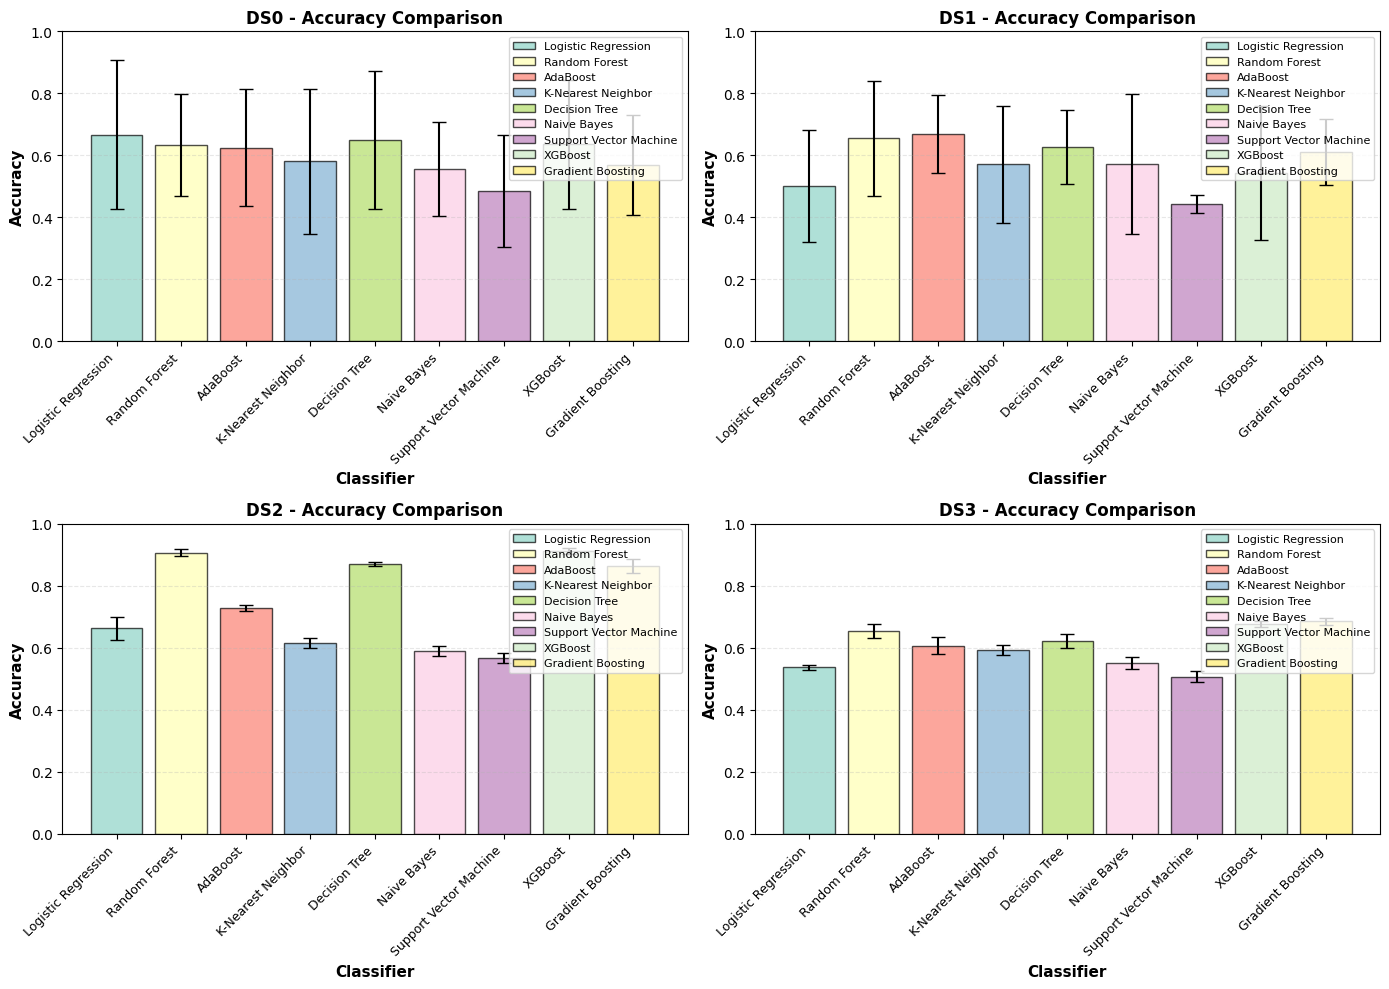


✓ Accuracy comparison plot saved: results\paper\01_accuracy_comparison.png


In [47]:
from pathlib import Path

print("="*80)
print("SECTION 6: VISUALIZATIONS - ACCURACY COMPARISON")
print("="*80)

# Create results directory
results_dir = Path('results/paper')
results_dir.mkdir(parents=True, exist_ok=True)

# Accuracy Comparison Across All Datasets
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.ravel()

for idx, dataset_name in enumerate(['DS0', 'DS1', 'DS2', 'DS3']):
    ax = axes[idx]
    
    clf_names = list(results[dataset_name].keys())
    accuracies = [results[dataset_name][clf]['Accuracy'] for clf in clf_names]
    stds = [results[dataset_name][clf]['Accuracy_std'] for clf in clf_names]
    
    colors = plt.cm.Set3(np.linspace(0, 1, len(clf_names)))
    bars = ax.bar(range(len(clf_names)), accuracies, yerr=stds, capsize=5, color=colors, edgecolor='black', alpha=0.7)
    
    ax.set_xlabel('Classifier', fontsize=11, fontweight='bold')
    ax.set_ylabel('Accuracy', fontsize=11, fontweight='bold')
    ax.set_title(f'{dataset_name} - Accuracy Comparison', fontsize=12, fontweight='bold')
    ax.set_xticks(range(len(clf_names)))
    ax.set_xticklabels(clf_names, rotation=45, ha='right', fontsize=9)
    ax.set_ylim([0, 1.0])
    ax.grid(axis='y', alpha=0.3, linestyle='--')
    ax.legend(bars, clf_names, loc='upper right', fontsize=8)

plt.tight_layout()
plt.savefig(results_dir / '01_accuracy_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\n✓ Accuracy comparison plot saved: {results_dir / '01_accuracy_comparison.png'}")

SECTION 6: VISUALIZATIONS - ROC CURVES


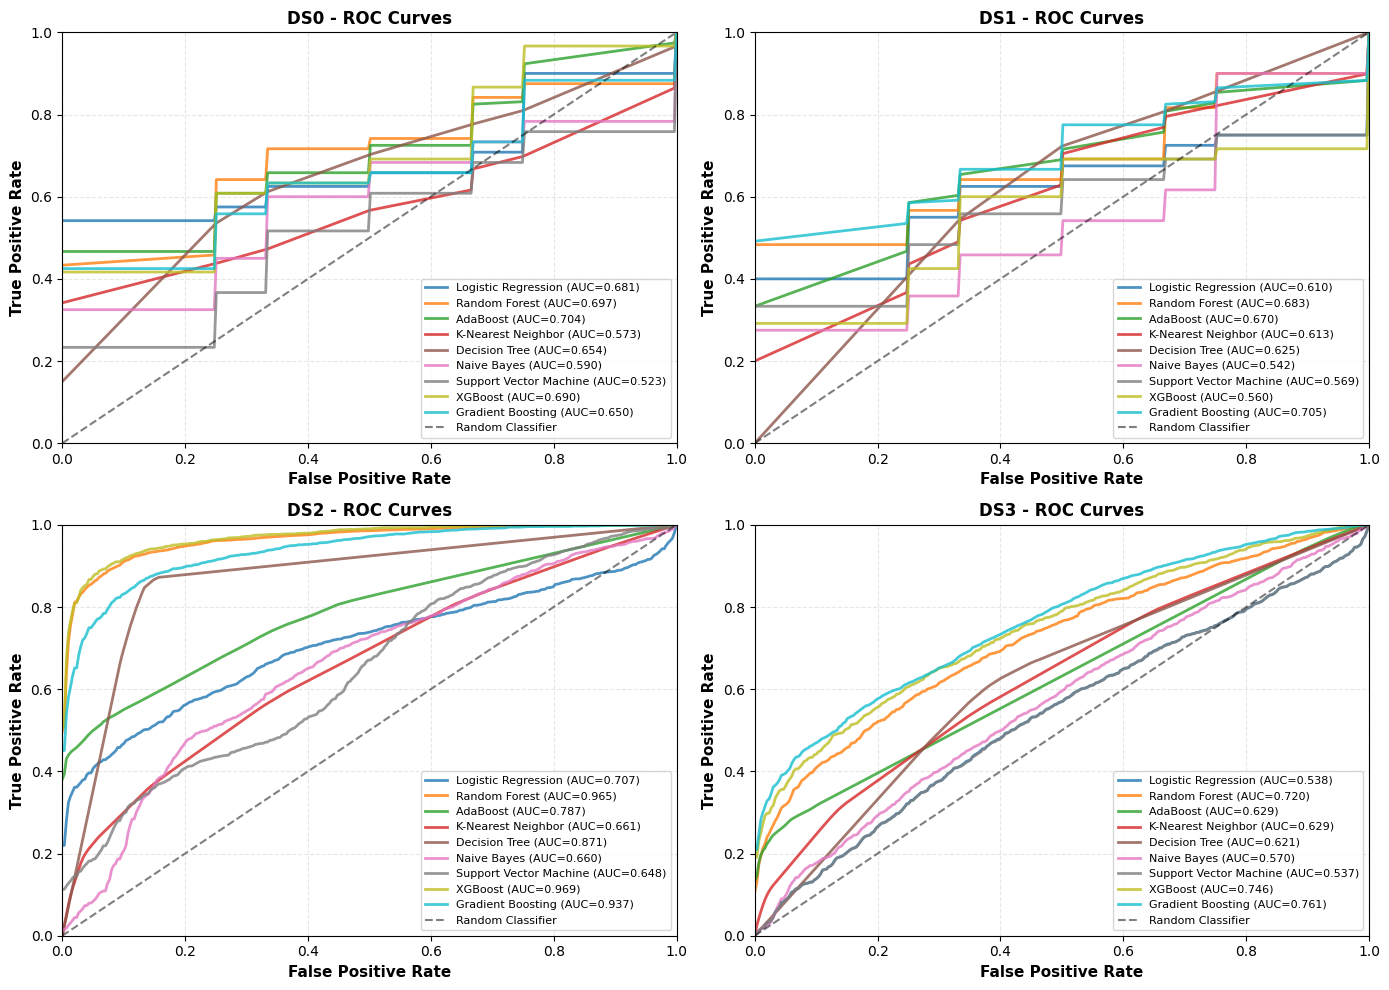


✓ ROC curves saved: results\paper\02_roc_curves.png


In [48]:
print("="*80)
print("SECTION 6: VISUALIZATIONS - ROC CURVES")
print("="*80)

# ROC Curves per Dataset
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.ravel()

for idx, dataset_name in enumerate(['DS0', 'DS1', 'DS2', 'DS3']):
    ax = axes[idx]
    colors = plt.cm.tab10(np.linspace(0, 1, len(classifiers)))
    
    for clf_idx, (clf_name, clf) in enumerate(classifiers.items()):
        # Average ROC curve across 10 folds
        fpr_list = [results[dataset_name][clf_name]['ROC_Curves'][i][0] for i in range(10)]
        tpr_list = [results[dataset_name][clf_name]['ROC_Curves'][i][1] for i in range(10)]
        
        # Interpolate to common FPR
        mean_fpr = np.linspace(0, 1, 300)
        tpr_interp = np.zeros_like(mean_fpr)
        for fpr, tpr in zip(fpr_list, tpr_list):
            tpr_interp += np.interp(mean_fpr, fpr, tpr)
        tpr_interp /= len(fpr_list)
        
        # Calculate AUC
        roc_auc = results[dataset_name][clf_name]['AUC']
        
        ax.plot(mean_fpr, tpr_interp, color=colors[clf_idx], lw=2, 
                label=f'{clf_name} (AUC={roc_auc:.3f})', alpha=0.8)
    
    # Diagonal line
    ax.plot([0, 1], [0, 1], 'k--', lw=1.5, alpha=0.5, label='Random Classifier')
    
    ax.set_xlabel('False Positive Rate', fontsize=11, fontweight='bold')
    ax.set_ylabel('True Positive Rate', fontsize=11, fontweight='bold')
    ax.set_title(f'{dataset_name} - ROC Curves', fontsize=12, fontweight='bold')
    ax.legend(loc='lower right', fontsize=8)
    ax.grid(alpha=0.3, linestyle='--')
    ax.set_xlim([0, 1])
    ax.set_ylim([0, 1])

plt.tight_layout()
plt.savefig(results_dir / '02_roc_curves.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\n✓ ROC curves saved: {results_dir / '02_roc_curves.png'}")

SECTION 6: VISUALIZATIONS - AUC, F1, MEMORY, AND TIME


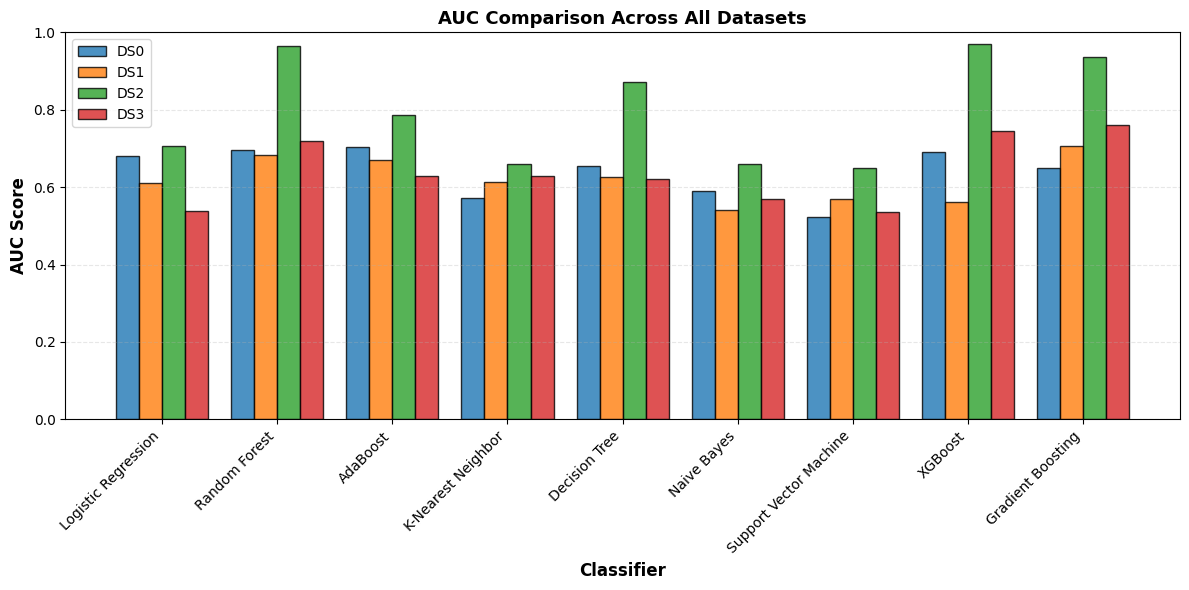


✓ AUC comparison plot saved: results\paper\03_auc_comparison.png


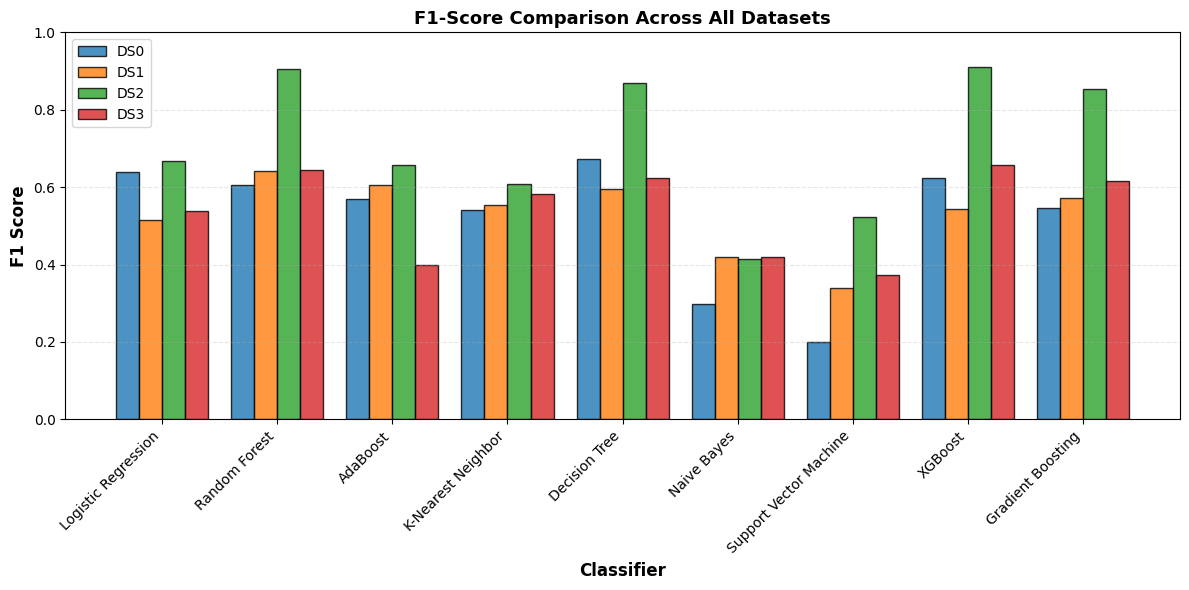

✓ F1-score comparison plot saved: results\paper\04_f1_comparison.png


C:\Users\cefalo\AppData\Local\Temp\ipykernel_28040\2243675372.py:67: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(clf_names, rotation=45, ha='right')


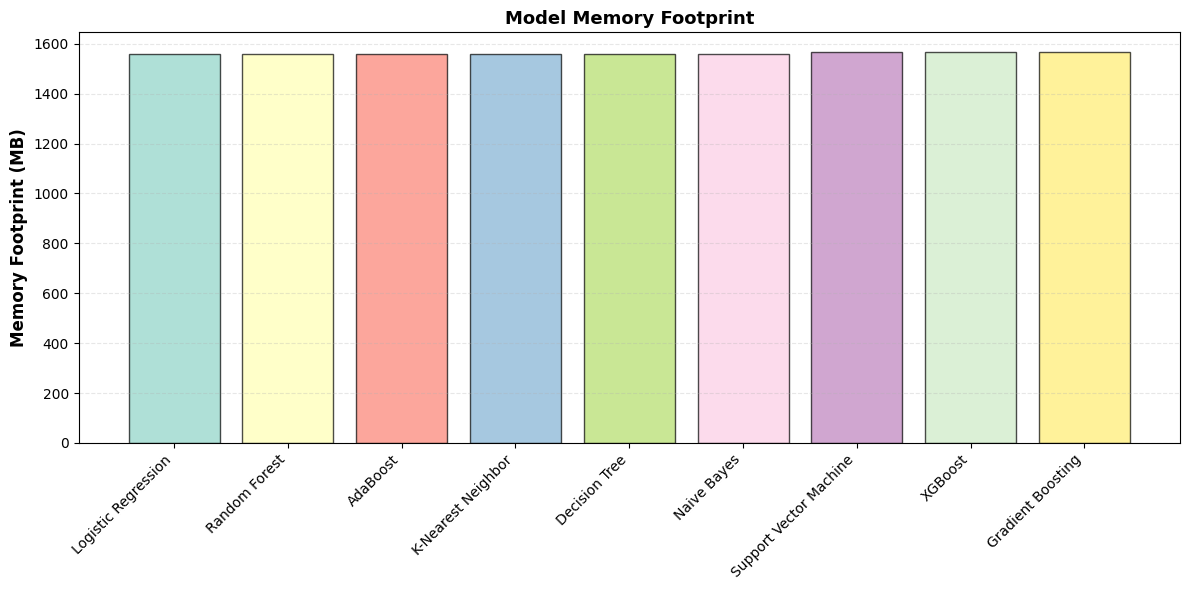

✓ Memory footprint plot saved: results\paper\05_memory_comparison.png


C:\Users\cefalo\AppData\Local\Temp\ipykernel_28040\2243675372.py:92: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(clf_names, rotation=45, ha='right')


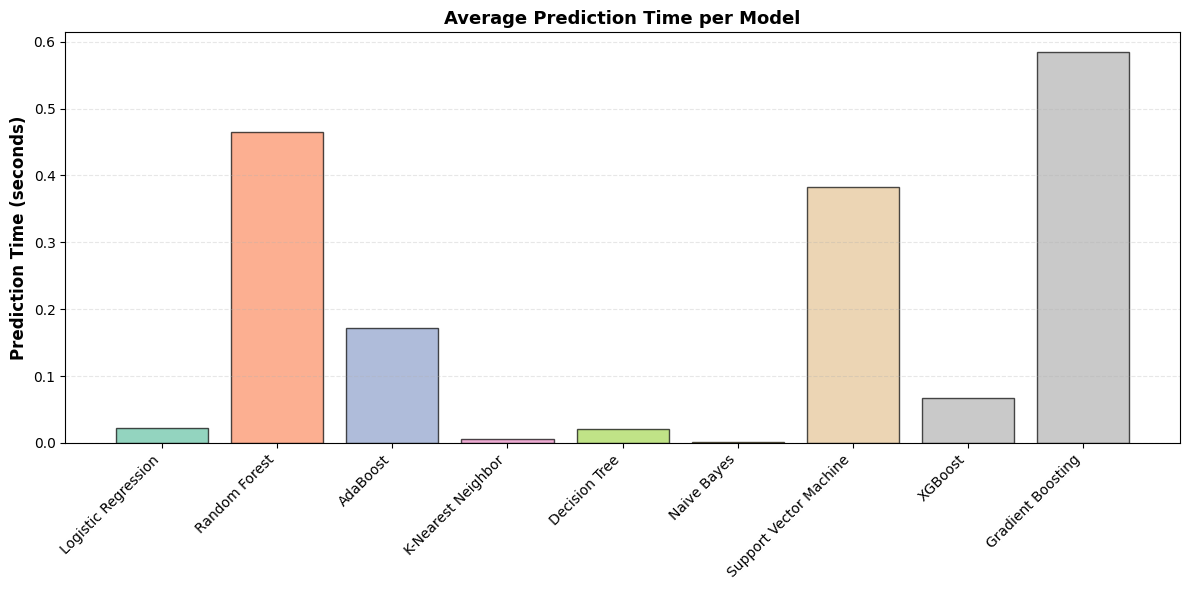

✓ Prediction time plot saved: results\paper\06_prediction_time.png


In [49]:
print("="*80)
print("SECTION 6: VISUALIZATIONS - AUC, F1, MEMORY, AND TIME")
print("="*80)

# AUC Comparison
fig, ax = plt.subplots(1, 1, figsize=(12, 6))
x_pos = np.arange(len(classifiers))
width = 0.2

for idx, dataset_name in enumerate(['DS0', 'DS1', 'DS2', 'DS3']):
    aucs = [results[dataset_name][clf_name]['AUC'] for clf_name in classifiers.keys()]
    ax.bar(x_pos + idx*width, aucs, width, label=dataset_name, alpha=0.8, edgecolor='black')

ax.set_xlabel('Classifier', fontsize=12, fontweight='bold')
ax.set_ylabel('AUC Score', fontsize=12, fontweight='bold')
ax.set_title('AUC Comparison Across All Datasets', fontsize=13, fontweight='bold')
ax.set_xticks(x_pos + 1.5*width)
ax.set_xticklabels(classifiers.keys(), rotation=45, ha='right')
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.3, linestyle='--')
ax.set_ylim([0, 1.0])

plt.tight_layout()
plt.savefig(results_dir / '03_auc_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\n✓ AUC comparison plot saved: {results_dir / '03_auc_comparison.png'}")

# F1 Score Comparison
fig, ax = plt.subplots(1, 1, figsize=(12, 6))

for idx, dataset_name in enumerate(['DS0', 'DS1', 'DS2', 'DS3']):
    f1s = [results[dataset_name][clf_name]['F1'] for clf_name in classifiers.keys()]
    ax.bar(x_pos + idx*width, f1s, width, label=dataset_name, alpha=0.8, edgecolor='black')

ax.set_xlabel('Classifier', fontsize=12, fontweight='bold')
ax.set_ylabel('F1 Score', fontsize=12, fontweight='bold')
ax.set_title('F1-Score Comparison Across All Datasets', fontsize=13, fontweight='bold')
ax.set_xticks(x_pos + 1.5*width)
ax.set_xticklabels(classifiers.keys(), rotation=45, ha='right')
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.3, linestyle='--')
ax.set_ylim([0, 1.0])

plt.tight_layout()
plt.savefig(results_dir / '04_f1_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"✓ F1-score comparison plot saved: {results_dir / '04_f1_comparison.png'}")

# Memory Footprint Comparison
fig, ax = plt.subplots(1, 1, figsize=(12, 6))

# Get memory for each model (averaged across datasets)
memory_by_clf = {}
for clf_name in classifiers.keys():
    memories = [results[dataset_name][clf_name]['Memory'] for dataset_name in datasets.keys()]
    memory_by_clf[clf_name] = np.mean(memories)

clf_names = list(memory_by_clf.keys())
memory_values = list(memory_by_clf.values())
colors = plt.cm.Set3(np.linspace(0, 1, len(clf_names)))

bars = ax.bar(clf_names, memory_values, color=colors, edgecolor='black', alpha=0.7)
ax.set_ylabel('Memory Footprint (MB)', fontsize=12, fontweight='bold')
ax.set_title('Model Memory Footprint', fontsize=13, fontweight='bold')
ax.set_xticklabels(clf_names, rotation=45, ha='right')
ax.grid(axis='y', alpha=0.3, linestyle='--')

plt.tight_layout()
plt.savefig(results_dir / '05_memory_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"✓ Memory footprint plot saved: {results_dir / '05_memory_comparison.png'}")

# Prediction Time Comparison
fig, ax = plt.subplots(1, 1, figsize=(12, 6))

# Get prediction time for each model (averaged across datasets)
time_by_clf = {}
for clf_name in classifiers.keys():
    times = [results[dataset_name][clf_name]['Time'] for dataset_name in datasets.keys()]
    time_by_clf[clf_name] = np.mean(times)

clf_names = list(time_by_clf.keys())
time_values = list(time_by_clf.values())
colors = plt.cm.Set2(np.linspace(0, 1, len(clf_names)))

bars = ax.bar(clf_names, time_values, color=colors, edgecolor='black', alpha=0.7)
ax.set_ylabel('Prediction Time (seconds)', fontsize=12, fontweight='bold')
ax.set_title('Average Prediction Time per Model', fontsize=13, fontweight='bold')
ax.set_xticklabels(clf_names, rotation=45, ha='right')
ax.grid(axis='y', alpha=0.3, linestyle='--')

plt.tight_layout()
plt.savefig(results_dir / '06_prediction_time.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"✓ Prediction time plot saved: {results_dir / '06_prediction_time.png'}")

SECTION 6: VISUALIZATIONS - CONFUSION MATRICES (SAMPLE)


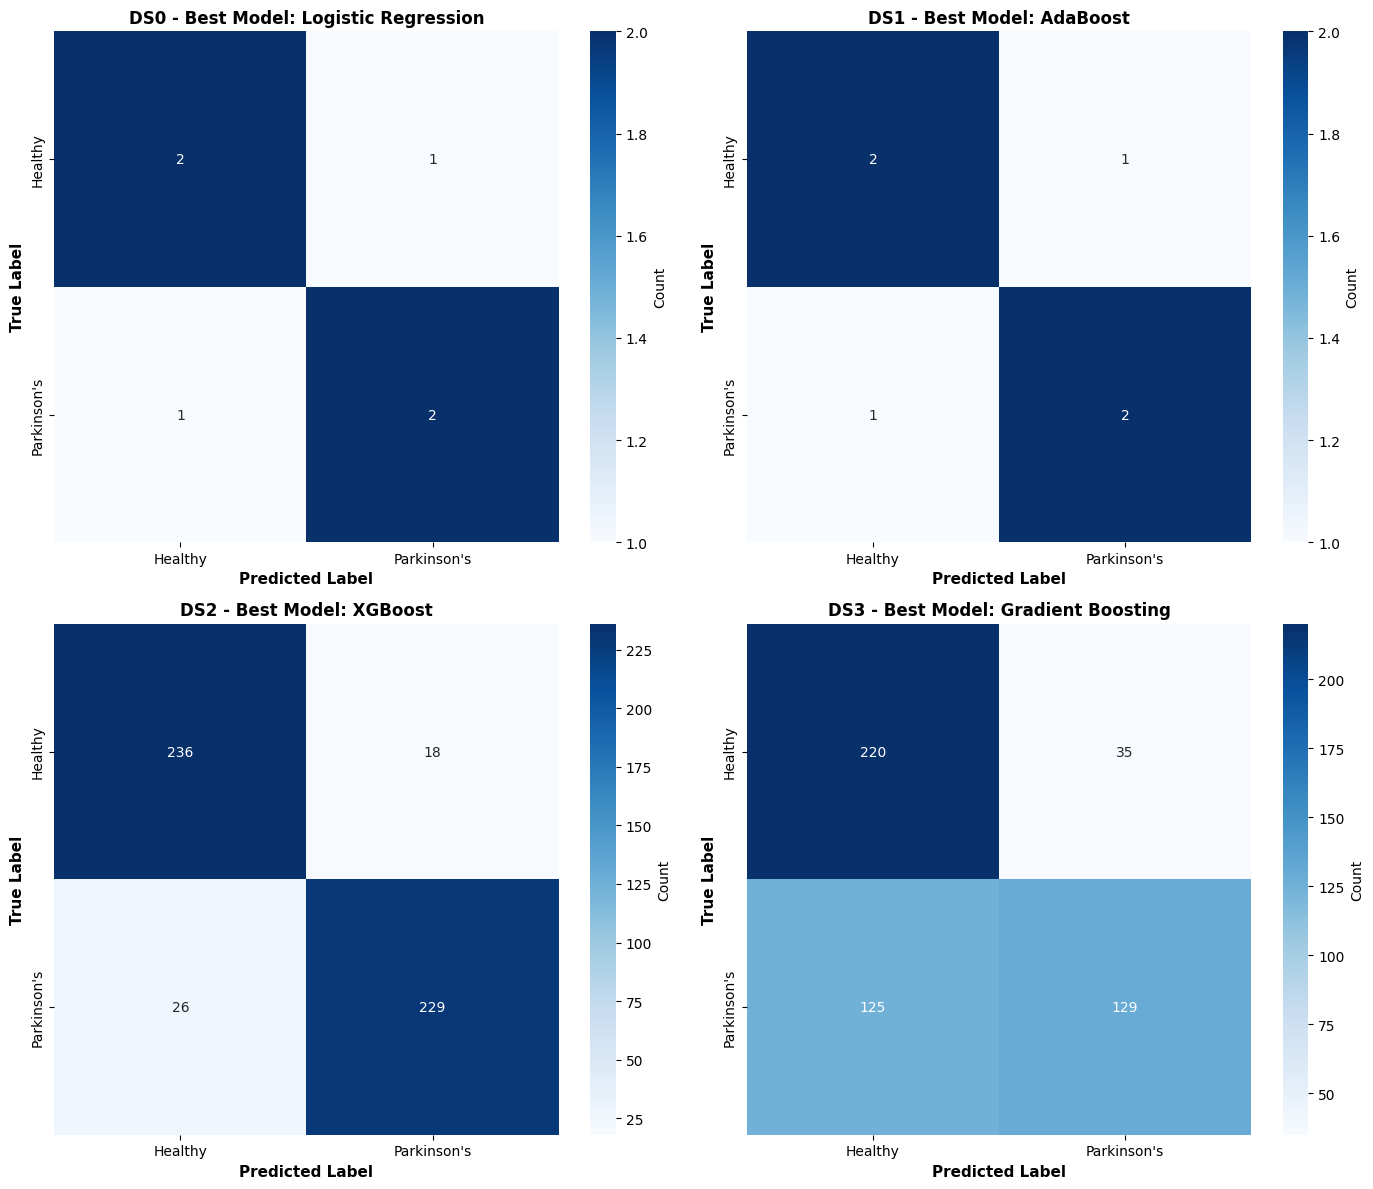


✓ Confusion matrices plot saved: results\paper\07_confusion_matrices.png


In [50]:
print("="*80)
print("SECTION 6: VISUALIZATIONS - CONFUSION MATRICES (SAMPLE)")
print("="*80)

# Show confusion matrices for best models on each dataset
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
axes = axes.ravel()

for idx, dataset_name in enumerate(['DS0', 'DS1', 'DS2', 'DS3']):
    ax = axes[idx]
    
    # Find best classifier for this dataset
    best_clf = max(results[dataset_name].items(), key=lambda x: x[1]['Accuracy'])[0]
    cm = results[dataset_name][best_clf]['Confusion_Matrix'].astype(int)
    
    # Plot confusion matrix
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=True, ax=ax,
                xticklabels=['Healthy', "Parkinson's"],
                yticklabels=['Healthy', "Parkinson's"],
                cbar_kws={'label': 'Count'})
    
    ax.set_xlabel('Predicted Label', fontsize=11, fontweight='bold')
    ax.set_ylabel('True Label', fontsize=11, fontweight='bold')
    ax.set_title(f'{dataset_name} - Best Model: {best_clf}', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig(results_dir / '07_confusion_matrices.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\n✓ Confusion matrices plot saved: {results_dir / '07_confusion_matrices.png'}")

In [51]:
print("="*80)
print("SECTION 7: FINAL ANALYSIS - COMPARISON TABLES")
print("="*80)

# Create comprehensive comparison tables
print("\n" + "="*80)
print("ACCURACY COMPARISON TABLE")
print("="*80)

accuracy_data = []
for clf_name in classifiers.keys():
    row = {'Classifier': clf_name}
    for dataset_name in datasets.keys():
        acc = results[dataset_name][clf_name]['Accuracy']
        row[dataset_name] = f"{acc:.4f}"
    accuracy_data.append(row)

accuracy_df = pd.DataFrame(accuracy_data)
print(accuracy_df.to_string(index=False))

print("\n" + "="*80)
print("AUC COMPARISON TABLE")
print("="*80)

auc_data = []
for clf_name in classifiers.keys():
    row = {'Classifier': clf_name}
    for dataset_name in datasets.keys():
        auc_val = results[dataset_name][clf_name]['AUC']
        row[dataset_name] = f"{auc_val:.4f}"
    auc_data.append(row)

auc_df = pd.DataFrame(auc_data)
print(auc_df.to_string(index=False))

print("\n" + "="*80)
print("F1-SCORE COMPARISON TABLE")
print("="*80)

f1_data = []
for clf_name in classifiers.keys():
    row = {'Classifier': clf_name}
    for dataset_name in datasets.keys():
        f1_val = results[dataset_name][clf_name]['F1']
        row[dataset_name] = f"{f1_val:.4f}"
    f1_data.append(row)

f1_df = pd.DataFrame(f1_data)
print(f1_df.to_string(index=False))

print("\n" + "="*80)
print("MEMORY FOOTPRINT COMPARISON (MB)")
print("="*80)

memory_data = []
for clf_name in classifiers.keys():
    row = {'Classifier': clf_name}
    for dataset_name in datasets.keys():
        mem = results[dataset_name][clf_name]['Memory']
        row[dataset_name] = f"{mem:.2f}"
    memory_data.append(row)

memory_df = pd.DataFrame(memory_data)
print(memory_df.to_string(index=False))

print("\n" + "="*80)
print("PREDICTION TIME COMPARISON (seconds)")
print("="*80)

time_data = []
for clf_name in classifiers.keys():
    row = {'Classifier': clf_name}
    for dataset_name in datasets.keys():
        pred_time = results[dataset_name][clf_name]['Time']
        row[dataset_name] = f"{pred_time:.4f}"
    time_data.append(row)

time_df = pd.DataFrame(time_data)
print(time_df.to_string(index=False))

print("\n" + "="*80)
print("BEST PERFORMING MODELS")
print("="*80)

for dataset_name in datasets.keys():
    best_acc_clf = max(results[dataset_name].items(), key=lambda x: x[1]['Accuracy'])
    best_auc_clf = max(results[dataset_name].items(), key=lambda x: x[1]['AUC'])
    best_f1_clf = max(results[dataset_name].items(), key=lambda x: x[1]['F1'])
    
    print(f"\n{dataset_name}:")
    print(f"  Best Accuracy: {best_acc_clf[0]} ({best_acc_clf[1]['Accuracy']:.4f})")
    print(f"  Best AUC:      {best_auc_clf[0]} ({best_auc_clf[1]['AUC']:.4f})")
    print(f"  Best F1:       {best_f1_clf[0]} ({best_f1_clf[1]['F1']:.4f})")

print("\n" + "="*80)
print("DATASET PERFORMANCE SUMMARY")
print("="*80)

dataset_summary = []
for dataset_name in datasets.keys():
    avg_acc = np.mean([results[dataset_name][clf]['Accuracy'] for clf in classifiers.keys()])
    avg_auc = np.mean([results[dataset_name][clf]['AUC'] for clf in classifiers.keys()])
    avg_f1 = np.mean([results[dataset_name][clf]['F1'] for clf in classifiers.keys()])
    
    dataset_summary.append({
        'Dataset': dataset_name,
        'Avg Accuracy': f"{avg_acc:.4f}",
        'Avg AUC': f"{avg_auc:.4f}",
        'Avg F1': f"{avg_f1:.4f}"
    })

summary_df = pd.DataFrame(dataset_summary)
print(summary_df.to_string(index=False))

print("\n" + "="*80)
print("KEY OBSERVATIONS")
print("="*80)

# Find overall best dataset
best_dataset = max(datasets.keys(), key=lambda d: np.mean([results[d][clf]['Accuracy'] for clf in classifiers.keys()]))
best_dataset_acc = np.mean([results[best_dataset][clf]['Accuracy'] for clf in classifiers.keys()])

worst_dataset = min(datasets.keys(), key=lambda d: np.mean([results[d][clf]['Accuracy'] for clf in classifiers.keys()]))
worst_dataset_acc = np.mean([results[worst_dataset][clf]['Accuracy'] for clf in classifiers.keys()])

print(f"\n✓ Best performing dataset: {best_dataset} (avg accuracy: {best_dataset_acc:.4f})")
print(f"✓ Worst performing dataset: {worst_dataset} (avg accuracy: {worst_dataset_acc:.4f})")

# Compare DS0 vs DS2 (raw vs augmented with HoG)
ds0_acc = np.mean([results['DS0'][clf]['Accuracy'] for clf in classifiers.keys()])
ds2_acc = np.mean([results['DS2'][clf]['Accuracy'] for clf in classifiers.keys()])
augmentation_effect = ((ds2_acc - ds0_acc) / ds0_acc) * 100

print(f"\n✓ Augmentation Effect (DS0 → DS2): {augmentation_effect:+.2f}%")

# Compare DS0 vs DS1 (HoG vs Canny+Hessian on raw images)
ds1_acc = np.mean([results['DS1'][clf]['Accuracy'] for clf in classifiers.keys()])
hessian_effect = ((ds1_acc - ds0_acc) / ds0_acc) * 100

print(f"✓ Canny+Hessian Effect (DS0 → DS1): {hessian_effect:+.2f}%")

print("\n" + "="*80)
print("SAVING RESULTS TO CSV")
print("="*80)

# Save all comparison tables as CSV files
accuracy_df.to_csv(results_dir / '01_accuracy_comparison.csv', index=False)
print(f"✓ Accuracy comparison saved: {results_dir / '01_accuracy_comparison.csv'}")

auc_df.to_csv(results_dir / '02_auc_comparison.csv', index=False)
print(f"✓ AUC comparison saved: {results_dir / '02_auc_comparison.csv'}")

f1_df.to_csv(results_dir / '03_f1_comparison.csv', index=False)
print(f"✓ F1-score comparison saved: {results_dir / '03_f1_comparison.csv'}")

memory_df.to_csv(results_dir / '04_memory_comparison.csv', index=False)
print(f"✓ Memory footprint saved: {results_dir / '04_memory_comparison.csv'}")

time_df.to_csv(results_dir / '05_prediction_time.csv', index=False)
print(f"✓ Prediction time saved: {results_dir / '05_prediction_time.csv'}")

summary_df.to_csv(results_dir / '06_dataset_summary.csv', index=False)
print(f"✓ Dataset summary saved: {results_dir / '06_dataset_summary.csv'}")

# Save best performing models summary
best_models_data = []
for dataset_name in datasets.keys():
    best_acc_clf = max(results[dataset_name].items(), key=lambda x: x[1]['Accuracy'])
    best_auc_clf = max(results[dataset_name].items(), key=lambda x: x[1]['AUC'])
    best_f1_clf = max(results[dataset_name].items(), key=lambda x: x[1]['F1'])
    
    best_models_data.append({
        'Dataset': dataset_name,
        'Best Accuracy Model': best_acc_clf[0],
        'Best Accuracy Score': f"{best_acc_clf[1]['Accuracy']:.4f}",
        'Best AUC Model': best_auc_clf[0],
        'Best AUC Score': f"{best_auc_clf[1]['AUC']:.4f}",
        'Best F1 Model': best_f1_clf[0],
        'Best F1 Score': f"{best_f1_clf[1]['F1']:.4f}"
    })

best_models_df = pd.DataFrame(best_models_data)
best_models_df.to_csv(results_dir / '07_best_models.csv', index=False)
print(f"✓ Best models summary saved: {results_dir / '07_best_models.csv'}")

print("\n" + "="*80)
print(f"All results saved to: {results_dir}")
print("="*80)


SECTION 7: FINAL ANALYSIS - COMPARISON TABLES

ACCURACY COMPARISON TABLE
            Classifier    DS0    DS1    DS2    DS3
   Logistic Regression 0.6661 0.5000 0.6627 0.5370
         Random Forest 0.6339 0.6554 0.9075 0.6543
              AdaBoost 0.6250 0.6679 0.7289 0.6064
    K-Nearest Neighbor 0.5804 0.5714 0.6154 0.5933
         Decision Tree 0.6482 0.6268 0.8707 0.6213
           Naive Bayes 0.5554 0.5714 0.5900 0.5509
Support Vector Machine 0.4857 0.4429 0.5677 0.5066
               XGBoost 0.6357 0.5429 0.9118 0.6764
     Gradient Boosting 0.5679 0.6107 0.8638 0.6852

AUC COMPARISON TABLE
            Classifier    DS0    DS1    DS2    DS3
   Logistic Regression 0.6813 0.6104 0.7070 0.5375
         Random Forest 0.6969 0.6833 0.9654 0.7198
              AdaBoost 0.7042 0.6698 0.7868 0.6292
    K-Nearest Neighbor 0.5729 0.6125 0.6605 0.6295
         Decision Tree 0.6542 0.6250 0.8707 0.6211
           Naive Bayes 0.5896 0.5417 0.6603 0.5703
Support Vector Machine 0.5229 0.5687 0

SECTION 8: CALIBRATION CURVES - DS0 vs DS2


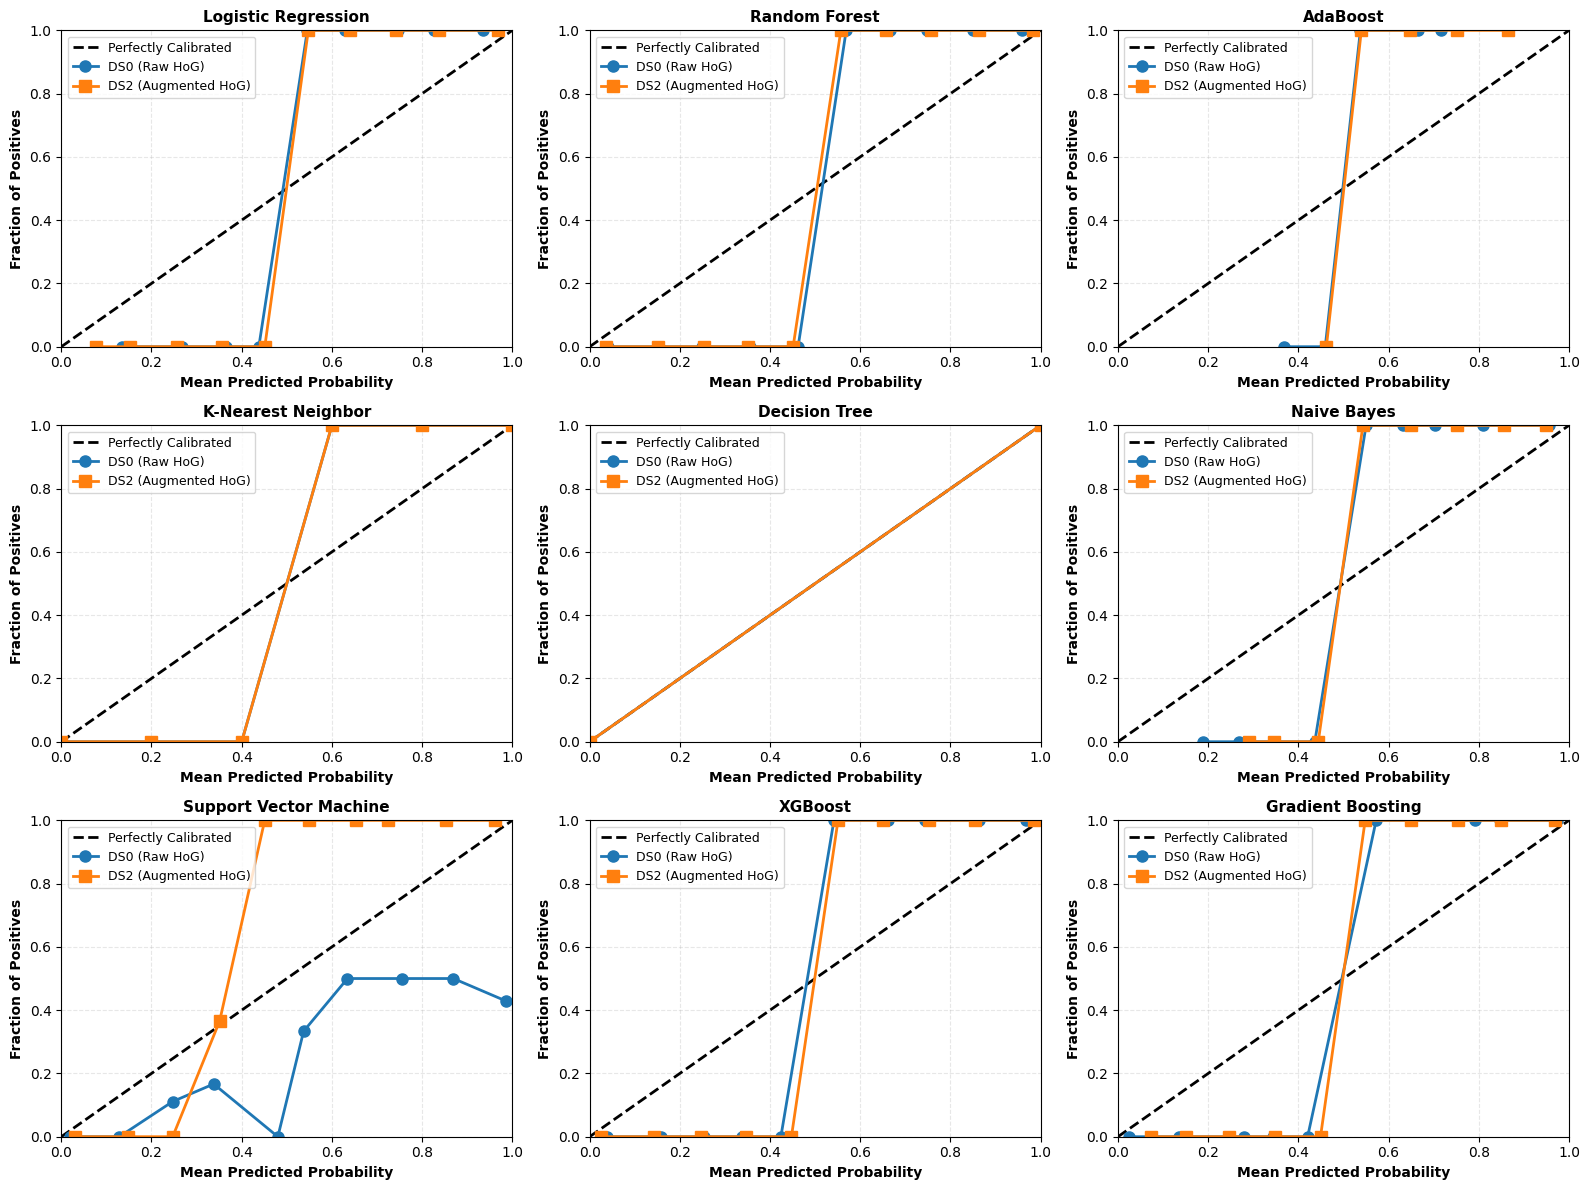


✓ Calibration curves plot saved: results\paper\08_calibration_curves.png


In [52]:
print("="*80)
print("SECTION 8: CALIBRATION CURVES - DS0 vs DS2")
print("="*80)

from sklearn.calibration import calibration_curve

fig, axes = plt.subplots(3, 3, figsize=(16, 12))
axes = axes.ravel()

for clf_idx, (clf_name, clf) in enumerate(classifiers.items()):
    ax = axes[clf_idx]
    
    # Collect all probabilities from DS0 (raw, HoG)
    ds0_all_probs = []
    ds0_all_labels = []
    for fold_idx in range(10):
        ds0_all_probs.extend(cv_probabilities['DS0'][clf_name][fold_idx])
        ds0_all_labels.extend(cv_predictions['DS0'][clf_name][fold_idx])
    
    ds0_all_probs = np.array(ds0_all_probs)
    ds0_all_labels = np.array(ds0_all_labels)
    
    # Collect all probabilities from DS2 (augmented, HoG)
    ds2_all_probs = []
    ds2_all_labels = []
    for fold_idx in range(10):
        ds2_all_probs.extend(cv_probabilities['DS2'][clf_name][fold_idx])
        ds2_all_labels.extend(cv_predictions['DS2'][clf_name][fold_idx])
    
    ds2_all_probs = np.array(ds2_all_probs)
    ds2_all_labels = np.array(ds2_all_labels)
    
    # Calculate calibration curves
    if len(np.unique(ds0_all_labels)) > 1:
        prob_true_ds0, prob_pred_ds0 = calibration_curve(ds0_all_labels, ds0_all_probs, n_bins=10)
    else:
        prob_true_ds0, prob_pred_ds0 = np.array([]), np.array([])
    
    if len(np.unique(ds2_all_labels)) > 1:
        prob_true_ds2, prob_pred_ds2 = calibration_curve(ds2_all_labels, ds2_all_probs, n_bins=10)
    else:
        prob_true_ds2, prob_pred_ds2 = np.array([]), np.array([])
    
    # Plot
    ax.plot([0, 1], [0, 1], 'k--', label='Perfectly Calibrated', lw=2)
    
    if len(prob_true_ds0) > 0:
        ax.plot(prob_pred_ds0, prob_true_ds0, 'o-', label='DS0 (Raw HoG)', lw=2, markersize=8)
    if len(prob_true_ds2) > 0:
        ax.plot(prob_pred_ds2, prob_true_ds2, 's-', label='DS2 (Augmented HoG)', lw=2, markersize=8)
    
    ax.set_xlabel('Mean Predicted Probability', fontsize=10, fontweight='bold')
    ax.set_ylabel('Fraction of Positives', fontsize=10, fontweight='bold')
    ax.set_title(f'{clf_name}', fontsize=11, fontweight='bold')
    ax.legend(loc='upper left', fontsize=9)
    ax.grid(alpha=0.3, linestyle='--')
    ax.set_xlim([0, 1])
    ax.set_ylim([0, 1])

plt.tight_layout()
plt.savefig(results_dir / '08_calibration_curves.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\n✓ Calibration curves plot saved: {results_dir / '08_calibration_curves.png'}")
print("="*80)